# Лабораторная работа №4: Поиск ассоциативных правил в транзакционных данных

## 1. Реализация Aprior

In [1]:
import time
import random
import seaborn as sns
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools


def apriori_gen(prev_itemsets, k, prev_itemsets_set):
    candidates = []
    n = len(prev_itemsets)
    for i in range(n):
        for j in range(i+1, n):
            a = prev_itemsets[i]
            b = prev_itemsets[j]
            if a[:-1] == b[:-1] and a[-1] < b[-1]:
                cand = a + (b[-1],)
                # проверка, что все (k-1)-подмножества нового кандидата частые
                subsets = itertools.combinations(cand, k-1)
                if all(tuple(sorted(sub)) in prev_itemsets_set for sub in subsets):
                    candidates.append(cand)
    return candidates

def apriori(transactions, min_support, max_len=5):
    n_trans = len(transactions)
    min_count = n_trans * min_support

    trans_sets = [set(t) for t in transactions]

    # частые 1эл наборы
    item_counts = defaultdict(int)
    for trans in trans_sets:
        for item in trans:
            item_counts[item] += 1

    freq_itemsets = {}
    for item, cnt in item_counts.items():
        if cnt >= min_count:
            freq_itemsets[(item,)] = cnt / n_trans

    if not freq_itemsets:
        return freq_itemsets

    # для циклов
    k = 2
    prev_freq_items = list(freq_itemsets.keys())
    prev_freq_set = set(prev_freq_items)

    while prev_freq_items and k <= max_len:
        # генерация кандидатов
        candidates = apriori_gen(prev_freq_items, k, prev_freq_set)
        if not candidates:
            break

        # поддержка кандидатов
        candidate_counts = defaultdict(int)
        for trans in trans_sets:
            for cand in candidates:
                if all(item in trans for item in cand):
                    candidate_counts[cand] += 1

        # фильтр по min_support
        new_freq = {}
        for cand, cnt in candidate_counts.items():
            if cnt >= min_count:
                new_freq[cand] = cnt / n_trans

        if not new_freq:
            break

        freq_itemsets.update(new_freq)
        prev_freq_items = list(new_freq.keys())
        prev_freq_set = set(prev_freq_items)
        k += 1

    return freq_itemsets

def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0,
                   max_antecedent_len=None, max_consequent_len=None):

    # генерация правил X -> Y
    rules = []
    for itemset, sup_XY in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for X in itertools.combinations(itemset, i):
                Y = tuple(sorted(set(itemset) - set(X)))
                if (max_antecedent_len and len(X) > max_antecedent_len) or \
                   (max_consequent_len and len(Y) > max_consequent_len):
                    continue
                sup_X = frequent_itemsets.get(X, 0)
                if sup_X == 0:
                    continue
                confidence = sup_XY / sup_X
                if confidence < min_confidence:
                    continue
                sup_Y = frequent_itemsets.get(Y, 0)
                if sup_Y == 0:
                    continue
                lift = confidence / sup_Y
                if lift < min_lift:
                    continue
                conviction = (1 - sup_Y) / (1 - confidence) if confidence < 1 else float('inf')
                leverage = sup_XY - (sup_X * sup_Y)
                rules.append((X, Y, sup_XY, confidence, lift, conviction, leverage))
    return rules

## 2. Реализация FP‑Growth

In [2]:
class FPNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

def build_fp_tree(transactions, min_support):
    n_trans = len(transactions)
    # первый проход: частоты
    item_counts = Counter()
    for trans in transactions:
        item_counts.update(trans)

    freq_items = {item: count for item, count in item_counts.items() if count / n_trans >= min_support}

    header_table = {item: [0, None, None] for item in freq_items}

    root = FPNode(None, 0, None)

    # второй проход: вставка
    for trans in transactions:
        filtered_trans = sorted([item for item in trans if item in freq_items],
                                key=lambda x: (-freq_items[x], x))

        current = root
        for item in filtered_trans:
            if item in current.children:
                child = current.children[item]
                child.count += 1
            else:
                child = FPNode(item, 1, current)
                current.children[item] = child

                if header_table[item][1] is None:
                    header_table[item][1] = child
                else:
                    header_table[item][2].node_link = child
                header_table[item][2] = child
            current = child
            header_table[item][0] += 1

    return root, header_table

def fpgrowth(transactions, min_support):
    freq_itemsets = {}

    def mine(header, prefix):
        for item in sorted(header.keys(), key=lambda x: header[x][0]):
            new_prefix = tuple(sorted(prefix + (item,)))
            freq_itemsets[new_prefix] = header[item][0] / len(transactions)

            cond_trans = []
            node = header[item][1]
            while node:
                path = []
                p = node.parent
                while p.item is not None:
                    path.append(p.item)
                    p = p.parent
                for _ in range(node.count): cond_trans.append(path)
                node = node.node_link

            if cond_trans:
                _, c_header = build_fp_tree(cond_trans, min_support)
                if c_header: mine(c_header, new_prefix)

    _, header = build_fp_tree(transactions, min_support)
    mine(header, ())
    return freq_itemsets

## 3. Выбор и загрузка реального датасета

In [3]:
df = pd.read_csv('../data/movies.csv')

print("Размер датасета:", df.shape)
df.info()
df.head()

# удаление пропусков
df = df.dropna(subset=['rating', 'genre', 'year', 'country', 'director', 'star'])
df = df.drop_duplicates(subset=['name'])

# доп признаки
df['decade'] = (df['year'] // 10).astype(str) + 's'
df['score_cat'] = pd.cut(df['score'], bins=[0, 6, 7.5, 10], labels=['low', 'medium', 'high'])

def make_itemset_raw(row):
    return {
        f"rating_{row['rating']}",
        f"genre_{row['genre']}",
        f"decade_{row['decade']}",
        f"country_{row['country']}",
        f"director_{row['director']}",
        f"star_{row['star']}",
        f"score_{row['score_cat']}"
    }
# строим транзакции
transactions_raw = df.apply(make_itemset_raw, axis=1).tolist()

# частота каждого элемента
from collections import Counter
item_counts = Counter()
for trans in transactions_raw:
    item_counts.update(trans)

# элементы, которые встречаются реже min_freq, сносим
min_freq = 30
transactions = []
for trans in transactions_raw:
    filtered = {item for item in trans if item_counts[item] >= min_freq}
    if filtered:                     # скипаем пустые транзакции
        transactions.append(filtered)

print(f"Транзакций после фильтрации: {len(transactions)}")
print(f"Уникальных элементов: {len(set(itertools.chain.from_iterable(transactions)))}")
print(f"Средняя длина транзакции: {np.mean([len(t) for t in transactions]):.2f}")

# частоты оставшихся элементов
item_counts_filtered = Counter(itertools.chain.from_iterable(transactions))
n_trans = len(transactions)
freq_df = pd.DataFrame(item_counts_filtered.items(), columns=['item', 'frequency'])
freq_df['support'] = freq_df['frequency'] / n_trans
freq_df = freq_df.sort_values('frequency', ascending=False)

print("\nТоп-5 элементов по частоте:")
print(freq_df.head(5).to_string(index=False))

Размер датасета: (7997, 15)
<class 'pandas.DataFrame'>
RangeIndex: 7997 entries, 0 to 7996
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7997 non-null   str    
 1   rating    7915 non-null   str    
 2   genre     7997 non-null   str    
 3   year      7997 non-null   int64  
 4   released  7995 non-null   str    
 5   score     7994 non-null   float64
 6   votes     7994 non-null   float64
 7   director  7995 non-null   str    
 8   writer    7994 non-null   str    
 9   star      7996 non-null   str    
 10  country   7992 non-null   str    
 11  budget    5715 non-null   float64
 12  gross     7787 non-null   float64
 13  company   7980 non-null   str    
 14  runtime   7993 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 937.3 KB
Транзакций после фильтрации: 7433
Уникальных элементов: 47
Средняя длина транзакции: 5.00

Топ-5 элементов по частоте:
                 item  frequency  

## 4. Эксперименты с параметрами и поиск правил



--- min_support = 0.01 ---
Частых наборов: 104
  min_confidence = 0.5: правил = 31
    Топ-5 по lift:
      ('country_United States', 'genre_Adventure') -> ('rating_PG',) : lift=3.06, conf=0.509
      ('decade_198s', 'rating_PG-13') -> ('genre_Comedy',) : lift=1.69, conf=0.502
      ('country_United Kingdom', 'rating_R') -> ('score_medium',) : lift=1.25, conf=0.716
      ('country_United Kingdom', 'rating_PG') -> ('score_medium',) : lift=1.25, conf=0.713
      ('country_United Kingdom',) -> ('score_medium',) : lift=1.24, conf=0.705
  min_confidence = 0.7: правил = 14
    Топ-5 по lift:
      ('country_United Kingdom', 'rating_R') -> ('score_medium',) : lift=1.25, conf=0.716
      ('country_United Kingdom', 'rating_PG') -> ('score_medium',) : lift=1.25, conf=0.713
      ('country_United Kingdom',) -> ('score_medium',) : lift=1.24, conf=0.705
      ('genre_Comedy', 'rating_PG-13') -> ('country_United States',) : lift=1.20, conf=0.862
      ('genre_Action', 'rating_PG-13') -> ('country_U

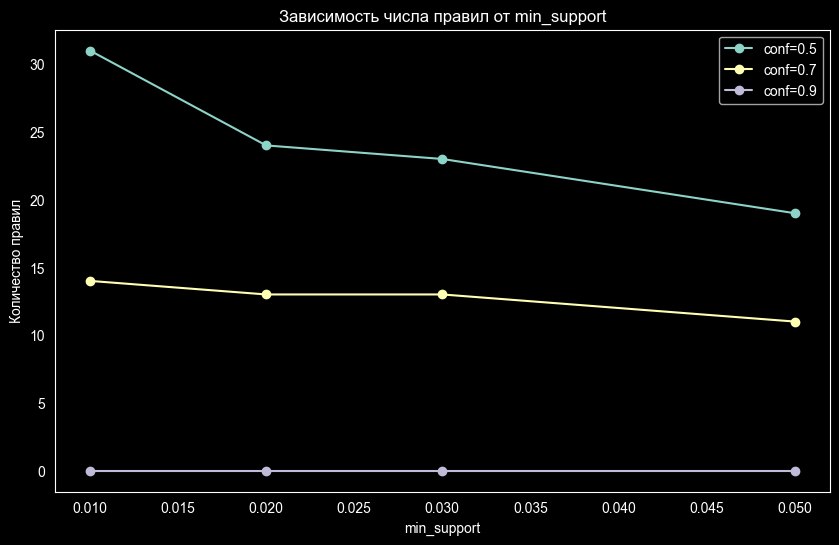

'\nПорог достоверности 0,9 оказался слишком строгим для моего набора данных, нет ни одного правила с достоверностью 90% и выше. Наиболее сильные правила имеют достоверность в диапазоне 50–86%.\n'

In [4]:
min_support_values = [0.01, 0.02, 0.03, 0.05]
min_conf_values = [0.5, 0.7, 0.9]

results = []

for supp in min_support_values:
    print(f"\n--- min_support = {supp} ---")
    freq_items = apriori(transactions, supp)
    print(f"Частых наборов: {len(freq_items)}")

    for conf in min_conf_values:
        rules = generate_rules(freq_items, min_confidence=conf, min_lift=1.0)

        print(f"  min_confidence = {conf}: правил = {len(rules)}")
        results.append({'min_support': supp, 'min_confidence': conf, 'num_rules': len(rules)})

        if rules:
            # сортировка по индексам
            top_lift = sorted(rules, key=lambda x: x[4], reverse=True)[:5]

            print(f"    Топ-5 по lift:")
            for r in top_lift:
                print(f"      {r[0]} -> {r[1]} : lift={r[4]:.2f}, conf={r[3]:.3f}")

# график
df_res = pd.DataFrame(results)
plt.figure(figsize=(10,6))
for conf in min_conf_values:
    data = df_res[df_res['min_confidence'] == conf]
    plt.plot(data['min_support'], data['num_rules'], marker='o', label=f'conf={conf}')

plt.xlabel('min_support')
plt.ylabel('Количество правил')
plt.title('Зависимость числа правил от min_support')
plt.legend()
plt.grid()
plt.show()
'''
Порог достоверности 0,9 оказался слишком строгим для моего набора данных, нет ни одного правила с достоверностью 90% и выше. Наиболее сильные правила имеют достоверность в диапазоне 50–86%.
'''

## 5. Сравнение производительности Apriori и FP‑Growth


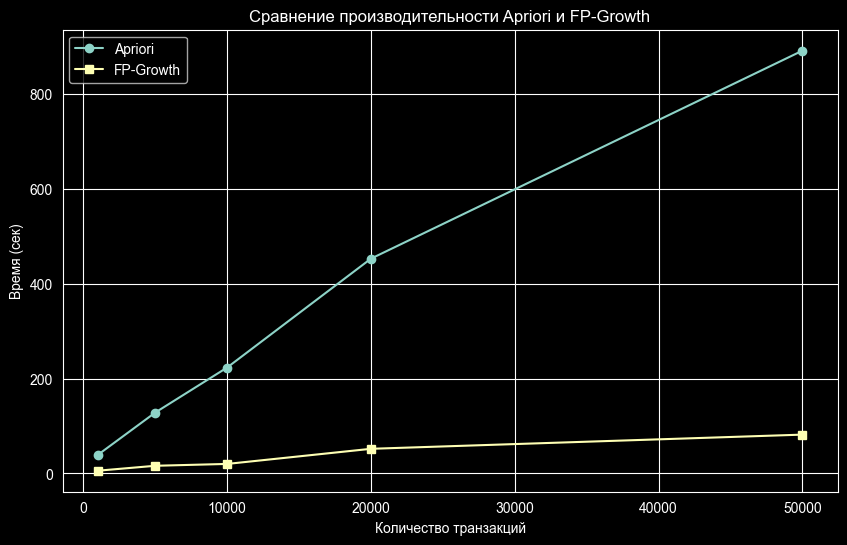

In [5]:
def generate_synthetic_data(n_trans, avg_len, n_items = 1000):
    transactions = []
    items = [f'item_{i}' for i in range(n_items)]

    probs = np.random.dirichlet(np.ones(n_items), size = 1)[0] # генерируем вероятности выбора каждого товара
    for _ in range(n_trans):
        length = np.random.poisson(avg_len) # генерируем длину транзакции
        length = max(2, min(length, n_items))
        trans = np.random.choice(items, size = length, replace = False, p = probs)
        transactions.append(list(trans))
    return transactions

np.random.seed(42)
random.seed(42)

min_supp = 0.02
trans_counts   = [1000, 5000, 10000, 20000, 50000]
avg_len = 10
times_apriori = []
times_fpg = []

for N in trans_counts:
    data = generate_synthetic_data(N, avg_len)

    start = time.time()
    freq_ap = apriori(data, min_supp)
    times_apriori.append(time.time() - start)

    start = time.time()
    freq_fp = fpgrowth(data, min_supp)
    times_fpg.append(time.time() - start)

# график времени выполнения
plt.figure(figsize = (10, 6))
plt.plot(trans_counts, times_apriori, marker = 'o', label = 'Apriori')
plt.plot(trans_counts, times_fpg, marker = 's', label = 'FP-Growth')
plt.xlabel('Количество транзакций')
plt.ylabel('Время (сек)')
plt.title('Сравнение производительности Apriori и FP-Growth')
plt.legend()
plt.grid(True)
plt.show()

Apriori:

Сложность: O( N * 2^d * M), где:
- N - количество транзакций
- 2^d - количество комбинаций товаров (в худшем случае, если все товары покупаются вместе, где d - количество уникальных товаров)
- M - средняя длина транзакции (это время проверки "входит ли набор в транзакцию?")

Причины медленной работы:
- Множественные сканирования БД - для каждого размера itemset (k=1, 2, 3, ...) требуется отдельный проход по всем данным
- Генерация кандидатов - рост числа кандидатов на каждом шаге
- Проверка всех кандидатов - каждая транзакция проверяется на наличие каждого кандидата

На графике: время растёт почти линейно с количеством транзакций

FP-Growth:

Сложность: O(N * M), где:
- N - количество транзакций
- M - средняя длина транзакции

Причины высокой эффективности:
- Всего 2 сканирования БД - одно для построения FP-дерева, второе для поиска правил в узлах дерева
- Сжатие данных - FP-дерево компактно хранит информацию о частых паттернах
- Рекурсивный поиск без генерации кандидатов
- Разделение на подзадачи - условные базы правил обрабатываются независимо

На графике: время растёт очень медленно, показывая отличную масштабируемость

##### Вывод: FP-Growth гораздо эффективнее для больших датасетов благодаря отсутствию генерации кандидатов и минимальному числу проходов по данным

## 6. Визуализация ассоциативных правил

Сгенерировано правил: 31


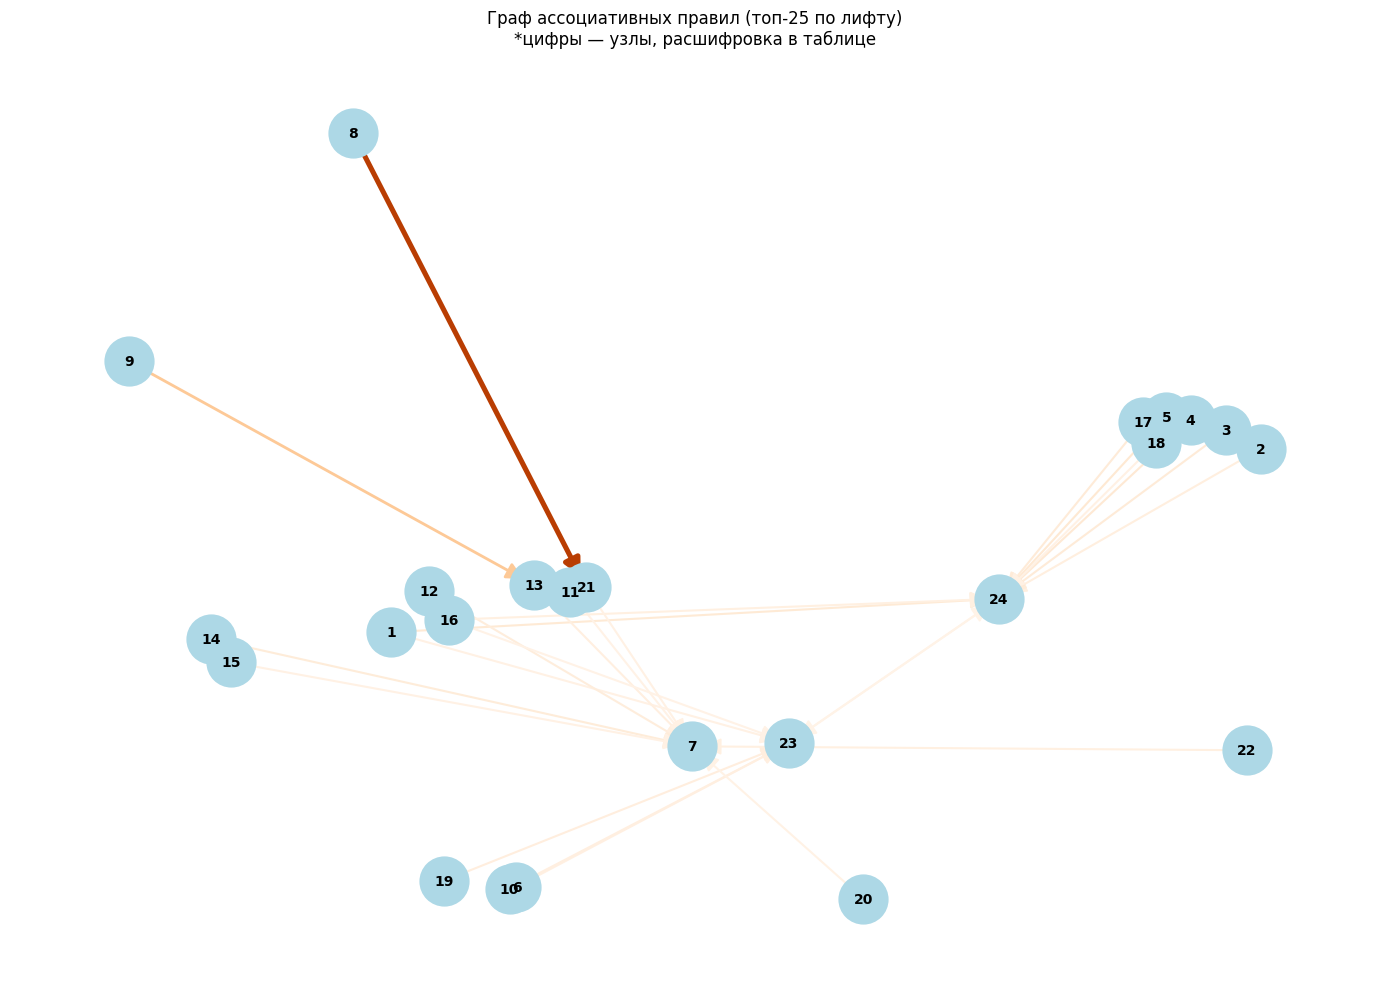


Легенда к графу:
 Номер                                Элементы
     1                  country_United Kingdom
     2   country_United Kingdom & genre_Action
     3   country_United Kingdom & genre_Comedy
     4      country_United Kingdom & rating_PG
     5       country_United Kingdom & rating_R
     6   country_United Kingdom & score_medium
     7                   country_United States
     8 country_United States & genre_Adventure
     9              decade_198s & rating_PG-13
    10                 decade_198s & score_low
    11                            genre_Action
    12             genre_Action & rating_PG-13
    13                            genre_Comedy
    14             genre_Comedy & rating_PG-13
    15             genre_Comedy & score_medium
    16                             genre_Drama
    17                 genre_Drama & rating_PG
    18                  genre_Drama & rating_R
    19                 genre_Drama & score_low
    20                            genre_Ho

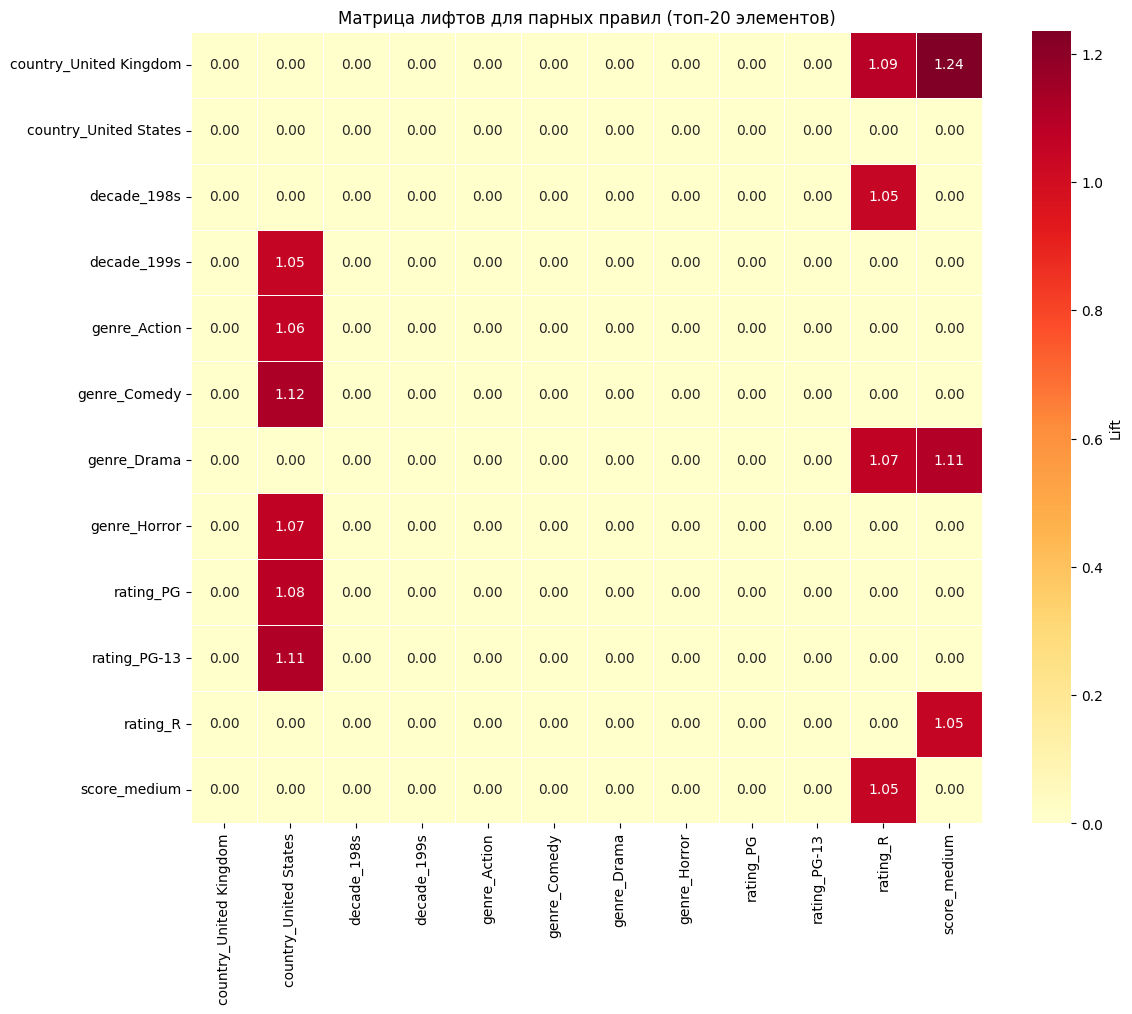

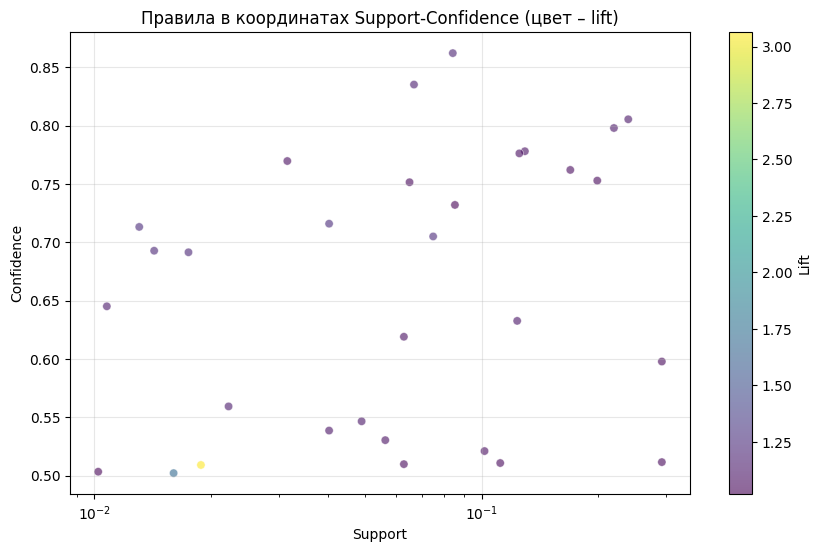

In [9]:
# используем правила, полученные при минимальной поддержке 0.01 и достоверности 0.5
freq_items_for_viz = apriori(transactions, min_support=0.01)
rules_for_viz = generate_rules(freq_items_for_viz, min_confidence=0.5, min_lift=1.0)

print(f"Сгенерировано правил: {len(rules_for_viz)}")

if not rules_for_viz:
    print("Нет правил для визуализации. Попробуйте снизить пороги.")
else:
    # 1. Граф ассоциаций (топ-25 по лифту)
    top_rules = sorted(rules_for_viz, key=lambda r: r[4], reverse=True)[:25]

    # уникальные тексты узлов
    all_texts = set()
    for r in top_rules:
        all_texts.add(' & '.join(r[0]))
        all_texts.add(' & '.join(r[1]))

    # присваиваем каждому тексту номер
    text_to_num = {txt: i+1 for i, txt in enumerate(sorted(all_texts))}

    # строим граф с цифрами
    G = nx.DiGraph()
    for txt, num in text_to_num.items():
        G.add_node(num, label=txt)

    for r in top_rules:
        ant = ' & '.join(r[0])
        cons = ' & '.join(r[1])
        G.add_edge(text_to_num[ant], text_to_num[cons], weight=r[4])

    # рисуем граф
    plt.figure(figsize=(14, 10))
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue', linewidths=1.5)
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    widths = [max(1.5, w * 1.2) for w in weights]
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=widths,
                          edge_color=weights, edge_vmin=1, edge_vmax=3.5,
                          arrows=True, arrowsize=25, edge_cmap=plt.cm.Oranges)
    labels = {node: node for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')
    plt.title('Граф ассоциативных правил (топ-25 по лифту)\n*цифры — узлы, расшифровка в таблице', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # легенда
    legend_rows = []
    for txt, num in text_to_num.items():
        legend_rows.append([num, txt])
    legend_df = pd.DataFrame(legend_rows, columns=['Номер', 'Элементы'])
    print("\nЛегенда к графу:")
    print(legend_df.to_string(index=False))

    # 2. Матрица лифтов для парных правил
    pair_rules = [r for r in rules_for_viz if len(r[0]) == 1 and len(r[1]) == 1]
    if pair_rules:
        top_pair_rules = sorted(pair_rules, key=lambda x: x[4], reverse=True)[:20]
        items = set()
        for rule in top_pair_rules:
            items.add(rule[0][0])
            items.add(rule[1][0])
        items = sorted(items)
        n = len(items)
        if n > 0:
            lift_mat = pd.DataFrame(np.zeros((n, n)), index=items, columns=items)
            for r in pair_rules:
                a = r[0][0]
                c = r[1][0]
                if a in items and c in items:
                    lift_mat.loc[a, c] = r[4]
            plt.figure(figsize=(12, 10))
            sns.heatmap(lift_mat, annot=True, fmt='.2f', cmap='YlOrRd', square=True,
                        linewidths=0.5, cbar_kws={'label': 'Lift'})
            plt.title('Матрица лифтов для парных правил (топ-20 элементов)')
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            print("Недостаточно элементов для построения матрицы лифтов.")
    else:
        print("Нет парных правил для построения матрицы лифтов.")

    # 3. Диаграмма рассеяния
    supports = [r[2] for r in rules_for_viz]
    confidences = [r[3] for r in rules_for_viz]
    lifts = [r[4] for r in rules_for_viz]

    plt.figure(figsize=(10, 6))
    sc = plt.scatter(supports, confidences, c=lifts, cmap='viridis', alpha=0.6, edgecolors='w', linewidth=0.5)
    plt.colorbar(sc, label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Правила в координатах Support-Confidence (цвет – lift)')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()

## 7. Интерпретация результатов


In [7]:
# если вдруг rules не определенные или пустые, пересчитываем
if 'rules' not in dir() or not rules:
    freq_items_for_output = apriori(transactions, min_support=0.01)
    rules = generate_rules(freq_items_for_output, min_confidence=0.5, min_lift=1.0)

if rules:
    sorted_rules = sorted(rules, key=lambda r: (r[4], r[3]), reverse=True)

    top_n = min(20, len(sorted_rules))
    max_ant_len = max(len(', '.join(r[0])) for r in sorted_rules[:top_n])
    max_cons_len = max(len(', '.join(r[1])) for r in sorted_rules[:top_n])

    # минимальная ширина колонок
    ant_width = max(max_ant_len, 30)
    cons_width = max(max_cons_len, 30)

    print("\nТоп-20 ассоциативных правил (по лифту):")
    print("-" * (ant_width + cons_width + 30))
    print(f"{'Антецедент':<{ant_width}} -> {'Консеквент':<{cons_width}} {'Поддержк':>8} {'Достов':>8} {'Лифт':>6}")
    print("-" * (ant_width + cons_width + 30))

    for rule in sorted_rules[:20]:
        ant_str = ', '.join(rule[0])
        cons_str = ', '.join(rule[1])
        print(f"{ant_str:<{ant_width}} -> {cons_str:<{cons_width}} {rule[2]:>8.4f} {rule[3]:>8.3f} {rule[4]:>6.2f}")
else:
    print("Нет правил для отображения. Попробуйте снизить min_support или min_confidence.")


Топ-20 ассоциативных правил (по лифту):
--------------------------------------------------------------------------------------------------
Антецедент                             -> Консеквент                     Поддержк   Достов   Лифт
--------------------------------------------------------------------------------------------------
country_United States, genre_Adventure -> rating_PG                        0.0188    0.509   3.06
decade_198s, rating_PG-13              -> genre_Comedy                     0.0160    0.502   1.69
country_United Kingdom, rating_R       -> score_medium                     0.0404    0.716   1.25
country_United Kingdom, rating_PG      -> score_medium                     0.0130    0.713   1.25
country_United Kingdom                 -> score_medium                     0.0749    0.705   1.24
genre_Drama, rating_PG                 -> score_medium                     0.0143    0.693   1.21
country_United Kingdom, genre_Comedy   -> score_medium                     


На основе анализа ассоциативных правил, полученных из датасета фильмов, можно сделать следующие выводы.

---

### 1. Какие свойства фильмов часто сочетаются?

- **Американские приключенческие фильмы и рейтинг PG**  
  Правило `country_United States, genre_Adventure → rating_PG` имеет **лифт 3.06** (наибольший). Это означает, что американские приключенческие фильмы в три раза чаще имеют рейтинг PG (для широкой аудитории), чем в среднем по датасету.

- **Драмы с рейтингом PG и 1980-е годы**  
  `genre_Drama, rating_PG → decade_1980s` (лифт 2.36, поддержка 1.1%). В 1980-х годах драмы с рейтингом PG (т.е. без возрастных ограничений) встречались значительно чаще, чем в другие десятилетия.

- **1980-е, рейтинг PG-13 и комедии**  
  `decade_198s, rating_PG-13 → genre_Comedy` (лифт 1.69). В 1980-х годах фильмы с рейтингом PG-13 были преимущественно комедиями.

- **Британское кино и средние оценки**  
  Несколько правил связывают фильмы из Великобритании (особенно драмы, комедии, боевики) с `score_medium` (лифт 1.24–1.31). Это может указывать на то, что британское кино в данной выборке редко получает очень высокие или очень низкие оценки, чаще «средние».

- **Комедии/боевики с рейтингом PG-13 и США**  
  `genre_Comedy, rating_PG-13 → country_United States` (лифт 1.20, достоверность 86.2%)  
  `genre_Action, rating_PG-13 → country_United States` (лифт 1.16, достоверность 83.5%)  
  Комедии и боевики с рейтингом PG-13 с высокой вероятностью произведены в США, что отражает доминирование Голливуда в этих жанрах.

- **Драмы с низкой оценкой и рейтинг R**  
  `genre_Drama, score_low → rating_R` (лифт 1.15). Низкие оценки у драм чаще связаны с рейтингом R (для взрослых).


### 2. Применение правил для рекомендаций и анализа трендов

- **Рекомендации по жанру и рейтингу**  
  Если пользователь смотрит американский приключенческий фильм, система может порекомендовать другие фильмы с рейтингом PG (семейные/детские).  
  Для зрителя, который любит комедии 80-х с рейтингом PG-13, можно сформировать подборку «Комедии 80-х».

- **Анализ десятилетних трендов**  
  Ассоциации `decade_1980s` с определёнными жанрами и рейтингами позволяют изучать, как менялись вкусы аудитории. Например, в 1980-х комедии чаще получали PG-13, а драмы с рейтингом PG были популярнее.

- Можно использовать для создания тематических подборок на стриминговых платформах.


### 3. Почему некоторые правила могут быть бесполезными?

- **Низкая поддержка**  
  Правила с поддержкой менее 1–2% (например, `genre_Drama, rating_PG → decade_1980s` – 1.06%) могут быть статистическим шумом. Если такая комбинация встретилась всего 79 раз в 7433 транзакциях, она может не воспроизводиться на новых данных.

- **Отсутствие причинно-следственной связи**  
  Высокий лифт не означает причину. Например, связь британских фильмов со `score_medium` не значит, что британское происхождение *вызывает* среднюю оценку – просто в выборке большинство британских фильмов имеют оценку 6–7.5. Если изменить состав выборки, правило может исчезнуть.

- **Очевидность и тривиальность**  
  Правила типа `genre_Comedy → country_United States` (лифт 1.12) или `rating_PG-13 → country_United States` (лифт 1.11) отражают общеизвестный факт: США доминируют в производстве комедий и фильмов с рейтингом PG-13.